# LiDAR Processing

``lidar.py`` takes a .laz file and generates a canopy height model and percent cover raster (or binary tif), which can be used as input to the rest of the shelter pipeline. You can download .laz files for any location in NSW at [ELVIS](https://elevation.fsdf.org.au/).

In [1]:
from shelterbelts.classifications.lidar import lidar
from shelterbelts.utils.filepaths import laz_sample, dem_h_sample

## Generating a binary raster using existing 'Tall Vegetation' classifications


In [2]:
counts, da_tree = lidar(
    laz_sample,
    category5=True,
    binary=True,
    resolution=1
)

Saved: ./TEST_counts_res1_cat5.tif
Saved: ./TEST_woodyveg_res1_cat5.tif


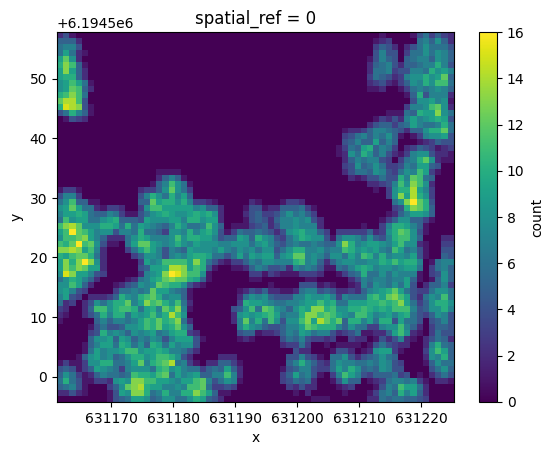

In [3]:
counts.plot()  # Number of points with the classification 'Tall Vegetation' in each pixel

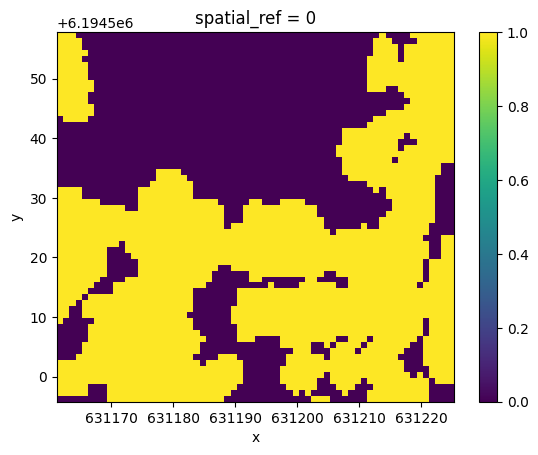

In [4]:
da_tree.plot() # binary tree raster

## Generating a Canopy Height Model with pdal's hag_nn algorithm

In [5]:
%%time
chm, da_tree = lidar(
    laz_sample,
    resolution=1
)

Saved: ./TEST_chm_res1.tif
Saved: ./TEST_percentcover_res1_height2m.tif
CPU times: user 19.2 ms, sys: 59.6 ms, total: 78.8 ms
Wall time: 91.4 ms


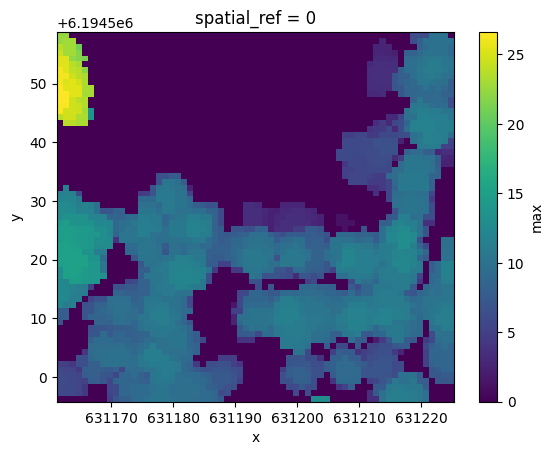

In [6]:
chm.plot() # Maximum height of a point in each pixel

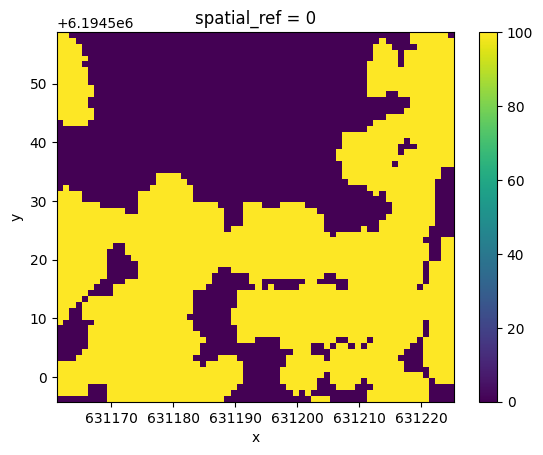

In [7]:
da_tree.plot()  # percent cover raster (but each pixel is 100% tree cover due to the matching resolution)

## Using a pre-computed DEM to speed up CHM generation

In [8]:
%%time
chm_dem, da_tree_dem = lidar(
    laz_sample,
    resolution=1,
    dem=dem_h_sample,
)
# This decreases processing time from 20 seconds to 3 seconds when using the original 1km x 1km laz file.

Saved: ./TEST_chm_res1.tif
Saved: ./TEST_percentcover_res1_height2m.tif
CPU times: user 27 ms, sys: 50.1 ms, total: 77.1 ms
Wall time: 89.9 ms


## Changing the height threshold

Saved: ./TEST_chm_res1.tif
Saved: ./TEST_percentcover_res1_height10m.tif


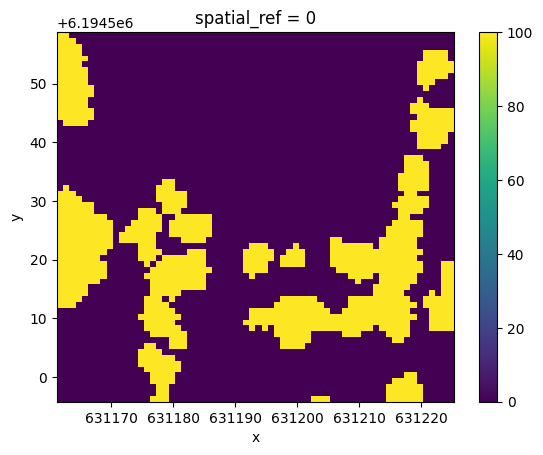

In [9]:
chm, da_tree = lidar(
    laz_sample,
    resolution=1,
    height_threshold=10 # metres
)
da_tree.plot()

## Changing the output resolution

Saved: ./TEST_chm_res1.tif
Saved: ./TEST_percentcover_res5_height2m.tif


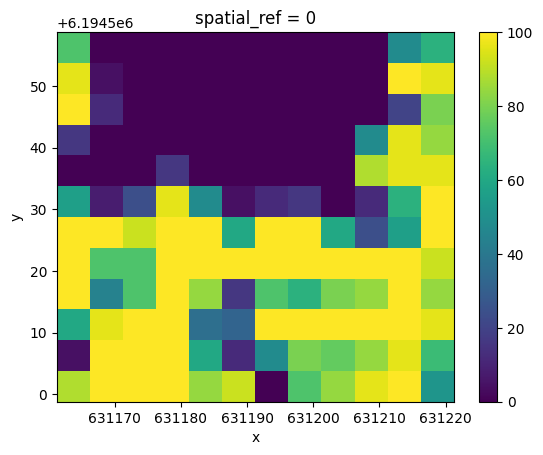

In [11]:
chm, da_tree = lidar(
    laz_sample,
    resolution=5 # metres
)
da_tree.plot() # Percent cover raster (now the edges only have partial tree cover)

## Delineating individual tree crowns

Setting ``delineate_crowns=True`` runs the pycrown Dalponte segmentation algorithm on
the CHM and saves a GeoPackage of crown polygons and height metrics for each tree.

In [12]:
chm, da_tree = lidar(
    laz_sample,
    delineate_crowns=True,
    stub='demo_crowns',
)

Saved: ./demo_crowns_chm_res1.tif
Saved: ./demo_crowns_crowns.gpkg (28 crowns)
Saved: ./demo_crowns_percentcover_res10_height2m.tif


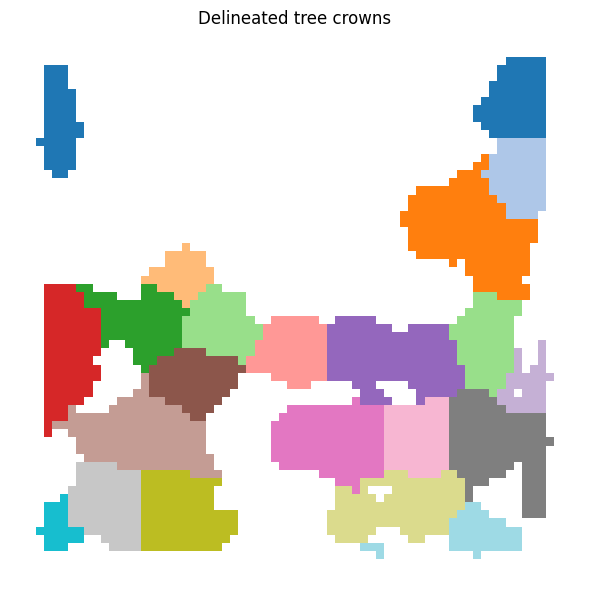

Number of tree crowns: 28


,treeID,mean_height_m,median_height_m,q3_height_m,p90_height_m,max_height_m,geometry
0,1,9.405694,9.700001,10.330000,10.693000,10.980000,"POLYGON ((631219.24 6194557.77, 631219.24 6194..."
1,2,23.650190,23.879999,25.247501,25.420000,26.610001,"POLYGON ((631162.24 6194556.77, 631162.24 6194..."
2,3,10.229366,10.880000,11.385000,11.665999,11.690000,"POLYGON ((631218.24 6194547.77, 631218.24 6194..."
3,4,5.145625,5.755000,6.020000,6.450000,8.150000,"POLYGON ((631216.24 6194545.77, 631216.24 6194..."
4,5,9.536250,10.030001,10.480000,10.710000,10.790000,"POLYGON ((631218.24 6194538.77, 631218.24 6194..."


In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf_crowns = gpd.read_file('demo_crowns_crowns.gpkg')
fig, ax = plt.subplots(figsize=(6, 6))
gdf_crowns.plot(column='treeID', cmap='tab20', ax=ax)
ax.set_title(f'Delineated tree crowns')
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Number of tree crowns: {len(gdf_crowns)}")
gdf_crowns.head()